# Global Cost of Living Analysis: Where Does Your Money Go?

This project analyzes global cost of living data to understand which countries and cities offer the best value for residents. Egypt serves as the anchor point, with a dedicated deep dive into how currency volatility and inflation have shaped the Egyptian economy from 2022 to 2026.

**Datasets used:**
- Cost of Living Index by Country (2024) — Numbeo via Kaggle
- Global Cost of Living by City — Numbeo via Kaggle
- USD/EGP Exchange Rate (2022–2026) — Investing.com
- Egypt Monthly Inflation (2022–2026) — Central Bank of Egypt

**Tools:** Python, pandas, numpy, matplotlib, seaborn




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## Phase 1: Data Loading & Exploration

Let's start by loading each dataset and understanding its structure before we do any cleaning or analysis.

### 1.1 Country-Level Cost of Living Index

In [2]:
country = pd.read_csv('data/raw/country_cost_of_living.csv')

print(f"Shape: {country.shape}")
print(f"\nData Types:\n {country.dtypes}")
print(f"\nMissing Values\n {country.isnull().sum()}")
country.head(10)

Shape: (121, 8)

Data Types:
 Rank                                int64
Country                               str
Cost of Living Index              float64
Rent Index                        float64
Cost of Living Plus Rent Index    float64
Groceries Index                   float64
Restaurant Price Index            float64
Local Purchasing Power Index      float64
dtype: object

Missing Values
 Rank                              0
Country                           0
Cost of Living Index              0
Rent Index                        0
Cost of Living Plus Rent Index    0
Groceries Index                   0
Restaurant Price Index            0
Local Purchasing Power Index      0
dtype: int64


,Rank,Country,Cost of Living Index,Rent Index,Cost of Living Plus Rent Index,Groceries Index,Restaurant Price Index,Local Purchasing Power Index
0,1,Switzerland,101.1,46.5,74.9,109.1,97.0,158.7
1,2,Bahamas,85.0,36.7,61.8,81.6,83.3,54.6
2,3,Iceland,83.0,39.2,62.0,88.4,86.8,120.3
3,4,Singapore,76.7,67.2,72.1,74.6,50.4,111.1
4,5,Barbados,76.6,19.0,48.9,80.8,69.4,43.5
5,6,Norway,76.0,26.2,52.1,79.0,73.5,114.7
6,7,Denmark,72.3,26.4,50.2,64.8,81.3,127.2
7,8,Hong Kong (China),70.8,59.4,65.3,84.6,46.2,109.3
8,9,United States,70.4,41.7,56.6,75.0,67.2,142.3
9,10,Australia,70.2,33.4,52.5,77.3,62.5,127.4


In [3]:
country.describe()

,Rank,Cost of Living Index,Rent Index,Cost of Living Plus Rent Index,Groceries Index,Restaurant Price Index,Local Purchasing Power Index
count,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000
mean,61.000000,43.555372,16.052893,30.357851,44.228926,36.471074,65.094215
std,35.073732,16.147574,11.412267,13.263721,17.055109,18.258110,39.569094
min,1.000000,18.800000,2.400000,11.100000,17.500000,12.800000,2.300000
25%,31.000000,30.200000,8.500000,19.800000,31.600000,21.600000,34.800000
50%,61.000000,39.500000,12.400000,27.000000,40.500000,33.100000,50.600000
75%,91.000000,52.800000,20.100000,37.000000,53.700000,47.200000,99.400000
max,121.000000,101.100000,67.200000,74.900000,109.100000,97.000000,182.500000


### 1.2 City-Level Cost of Living Data

In [4]:
city = pd.read_csv('data/raw/city_cost_of_living.csv')

print(f"Shape: {city.shape}")
print(f"\nData Types:\n{city.dtypes}")
print(f"\nMissing Values:\n{city.isnull().sum()}")
city.head(10)

Shape: (4874, 59)

Data Types:
Unnamed: 0        int64
city                str
country             str
x1              float64
x2              float64
x3              float64
x4              float64
x5              float64
x6              float64
x7              float64
x8              float64
x9              float64
x10             float64
x11             float64
x12             float64
x13             float64
x14             float64
x15             float64
x16             float64
x17             float64
x18             float64
x19             float64
x20             float64
x21             float64
x22             float64
x23             float64
x24             float64
x25             float64
x26             float64
x27             float64
x28             float64
x29             float64
x30             float64
x31             float64
x32             float64
x33             float64
x34             float64
x35             float64
x36             float64
x37             float64
x38      

,Unnamed: 0,city,country,x1,x2,x3,x4,x5,x6,x7,...,x47,x48,x49,x50,x51,x52,x53,x54,x55,data_quality
0,0,Delhi,India,4.90,22.04,4.28,1.84,3.67,1.78,0.48,...,36.26,223.87,133.38,596.16,325.82,2619.46,1068.90,586.35,7.96,1
1,1,Shanghai,China,5.59,40.51,5.59,1.12,4.19,3.96,0.52,...,121.19,1080.07,564.30,2972.57,1532.23,17333.09,9174.88,1382.83,5.01,1
2,2,Jakarta,Indonesia,2.54,22.25,3.50,2.02,3.18,2.19,0.59,...,80.32,482.85,270.15,1117.69,584.37,2694.05,1269.44,483.19,9.15,1
3,3,Manila,Philippines,3.54,27.40,3.54,1.24,1.90,2.91,0.93,...,61.82,559.52,281.78,1754.40,684.81,3536.04,2596.44,419.02,7.80,1
4,4,Seoul,South Korea,7.16,52.77,6.03,3.02,4.52,3.86,1.46,...,108.30,809.83,583.60,2621.05,1683.74,21847.94,10832.90,2672.23,3.47,1
5,5,Bangkok,Thailand,2.60,28.09,5.62,2.25,4.21,2.06,0.50,...,93.22,584.77,280.92,1994.97,915.48,5229.36,2504.73,615.33,5.64,1
6,6,Kolkata,India,2.00,14.69,3.67,2.20,3.67,1.60,0.36,...,32.30,148.95,84.21,397.89,247.53,1057.12,583.39,536.14,8.28,1
7,7,Guangzhou,China,4.05,27.94,4.89,0.84,1.68,3.41,0.44,...,46.25,523.26,311.48,1218.89,675.11,12650.42,5325.41,1189.07,5.11,1
8,8,Mumbai,India,3.67,18.36,3.67,2.45,4.28,2.49,0.46,...,41.04,514.39,285.88,1388.63,681.14,6073.04,2768.67,627.64,7.87,1
9,9,Beijing,China,4.19,30.73,5.59,1.40,4.05,4.55,0.51,...,117.38,1176.59,660.60,2732.46,1426.41,17450.87,9463.20,1514.55,5.00,1


### 1.3 USD/EGP Exchange Rate

In [5]:
exchange = pd.read_csv('data/raw/usd_egp_exchange_rate.csv')

print(f"Shape: {exchange.shape}")
print(f"\nData types:\n{exchange.dtypes}")
print(f"\nMissing values:\n{exchange.isnull().sum()}")
exchange.head()


Shape: (1455, 7)

Data types:
Date            str
Price       float64
Open        float64
High        float64
Low         float64
Vol.            str
Change %        str
dtype: object

Missing values:
Date           0
Price          0
Open           0
High           0
Low            0
Vol.        1260
Change %       0
dtype: int64


,Date,Price,Open,High,Low,Vol.,Change %
0,03/06/2026,50.14,50.15,50.15,50.14,NaN,0.08%
1,03/05/2026,50.10,50.17,50.38,50.04,NaN,-0.18%
2,03/04/2026,50.19,49.88,50.27,49.75,NaN,0.62%
3,03/03/2026,49.88,49.22,50.25,49.12,NaN,1.34%
4,03/02/2026,49.22,48.75,49.80,48.65,NaN,0.96%


### 1.4 Egypt Monthly Inflation (Central Bank of Egypt)

In [6]:
inflation = pd.read_excel('data/raw/egypt_inflation_monthly.xlsx', header=1)

print(f"Shape: {inflation.shape}")
print(f"\nData types:\n{inflation.dtypes}")
print(f"\nMissing values:\n{inflation.isnull().sum()}")
inflation.head()

Shape: (61, 5)

Data types:
Date                              str
Headline (y/y)                    str
Core (y/y)                        str
Regulated Items (y/y)             str
Fruits and Vegetables (y/y)    object
dtype: object

Missing values:
Date                            2
Headline (y/y)                 12
Core (y/y)                     12
Regulated Items (y/y)          12
Fruits and Vegetables (y/y)    12
dtype: int64


,Date,Headline (y/y),Core (y/y),Regulated Items (y/y),Fruits and Vegetables (y/y)
0,Jan 2026,11.900%,11.200%,15.400%,7.500%
1,Dec 2025,12.300%,11.800%,16.200%,4.400%
2,Nov 2025,12.300%,12.500%,16.500%,-3.600%
3,Oct 2025,12.500%,12.100%,18.100%,0.900%
4,Sep 2025,11.700%,11.300%,19.400%,-5.200%


## Phase 1 Observations 

Country dataset: clean, no missing values, ready to go
City dataset: 55 columns with generic names (x1-x55), has an unnecessary Unnamed: 0 column, significant missing values in some columns like salary and mortgage rate
Exchange rate: Date is a string not datetime, Volume column is mostly empty, Change % has percentage signs
Inflation: footnote rows creating fake missing values, all values are strings because of % signs, needs trimming

## Phase 2: Data Cleaning

Now we clean each dataset to prepare it for analysis. This includes fixing data types, removing unnecessary columns, handling missing values, and standardizing formats.

### 2.1 Cleaning Country-Level Data

In [7]:
country = country.drop(columns = ['Rank'])
print(f"Shape after cleaning: {country.shape}")
print(f"\nMissing values\n {country.isnull().sum()}")
country.head(10)

Shape after cleaning: (121, 7)

Missing values
 Country                           0
Cost of Living Index              0
Rent Index                        0
Cost of Living Plus Rent Index    0
Groceries Index                   0
Restaurant Price Index            0
Local Purchasing Power Index      0
dtype: int64


,Country,Cost of Living Index,Rent Index,Cost of Living Plus Rent Index,Groceries Index,Restaurant Price Index,Local Purchasing Power Index
0,Switzerland,101.1,46.5,74.9,109.1,97.0,158.7
1,Bahamas,85.0,36.7,61.8,81.6,83.3,54.6
2,Iceland,83.0,39.2,62.0,88.4,86.8,120.3
3,Singapore,76.7,67.2,72.1,74.6,50.4,111.1
4,Barbados,76.6,19.0,48.9,80.8,69.4,43.5
5,Norway,76.0,26.2,52.1,79.0,73.5,114.7
6,Denmark,72.3,26.4,50.2,64.8,81.3,127.2
7,Hong Kong (China),70.8,59.4,65.3,84.6,46.2,109.3
8,United States,70.4,41.7,56.6,75.0,67.2,142.3
9,Australia,70.2,33.4,52.5,77.3,62.5,127.4


### 2.2 Cleaning City-Level Data

In [8]:
# Drop the unnecessary index column
city = city.drop(columns=['Unnamed: 0'])

# Select and rename only the columns we need for analysis
columns_to_keep = {
    'city': 'city',
    'country': 'country',
    'x1': 'meal_inexpensive',
    'x2': 'meal_midrange',
    'x6': 'cappuccino',
    'x9': 'milk_1l',
    'x13': 'local_cheese_1kg',
    'x15': 'beef_1kg',
    'x28': 'oneway_ticket',
    'x29': 'monthly_pass',
    'x33': 'gasoline_1l',
    'x36': 'utilities_monthly',
    'x38': 'internet_monthly',
    'x41': 'cinema',
    'x48': 'rent_1bed_center',
    'x49': 'rent_1bed_outside',
    'x50': 'rent_3bed_center',
    'x51': 'rent_3bed_outside',
    'x54': 'avg_monthly_salary',
    'data_quality': 'data_quality'
}

city = city[list(columns_to_keep.keys())].rename(columns=columns_to_keep)

print(f"Shape after cleaning: {city.shape}")
print(f"\nColumns kept:\n{city.columns.tolist()}")
print(f"\nMissing values:\n{city.isnull().sum()}")
city.head()

Shape after cleaning: (4874, 20)

Columns kept:
['city', 'country', 'meal_inexpensive', 'meal_midrange', 'cappuccino', 'milk_1l', 'local_cheese_1kg', 'beef_1kg', 'oneway_ticket', 'monthly_pass', 'gasoline_1l', 'utilities_monthly', 'internet_monthly', 'cinema', 'rent_1bed_center', 'rent_1bed_outside', 'rent_3bed_center', 'rent_3bed_outside', 'avg_monthly_salary', 'data_quality']

Missing values:
city                     0
country                  0
meal_inexpensive       425
meal_midrange          442
cappuccino             334
milk_1l                380
local_cheese_1kg       481
beef_1kg               562
oneway_ticket         1473
monthly_pass          2124
gasoline_1l            578
utilities_monthly      474
internet_monthly       340
cinema                 469
rent_1bed_center      1341
rent_1bed_outside     1409
rent_3bed_center      1456
rent_3bed_outside     1489
avg_monthly_salary    1415
data_quality             0
dtype: int64


,city,country,meal_inexpensive,meal_midrange,cappuccino,milk_1l,local_cheese_1kg,beef_1kg,oneway_ticket,monthly_pass,gasoline_1l,utilities_monthly,internet_monthly,cinema,rent_1bed_center,rent_1bed_outside,rent_3bed_center,rent_3bed_outside,avg_monthly_salary,data_quality
0,Delhi,India,4.90,22.04,1.78,0.73,4.32,5.57,0.49,11.63,1.25,57.37,7.96,4.90,223.87,133.38,596.16,325.82,586.35,1
1,Shanghai,China,5.59,40.51,3.96,2.68,18.01,12.79,0.56,27.94,1.17,64.76,16.74,8.38,1080.07,564.30,2972.57,1532.23,1382.83,1
2,Jakarta,Indonesia,2.54,22.25,2.19,1.28,6.66,8.32,0.22,9.53,0.79,80.12,30.45,3.18,482.85,270.15,1117.69,584.37,483.19,1
3,Manila,Philippines,3.54,27.40,2.91,1.63,5.06,6.64,0.53,11.86,1.38,97.45,38.02,5.48,559.52,281.78,1754.40,684.81,419.02,1
4,Seoul,South Korea,7.16,52.77,3.86,2.13,11.13,40.41,0.98,41.47,1.41,176.24,22.06,9.42,809.83,583.60,2621.05,1683.74,2672.23,1


### 2.3 Cleaning Exchange Rate Data

In [9]:

exchange = exchange.drop(columns=['Vol.'])
exchange['Change %'] = exchange['Change %'].str.replace('%', '').astype(float)
exchange['Date'] = pd.to_datetime(exchange['Date'])
exchange = exchange.sort_values('Date').reset_index(drop=True)

print(f"Shape after cleaning: {exchange.shape}")
print(f"\nData types:\n{exchange.dtypes}")
print(f"\nDate range: {exchange['Date'].min()} to {exchange['Date'].max()}")
exchange.head()

Shape after cleaning: (1455, 6)

Data types:
Date        datetime64[us]
Price              float64
Open               float64
High               float64
Low                float64
Change %           float64
dtype: object

Date range: 2022-01-01 00:00:00 to 2026-03-06 00:00:00


,Date,Price,Open,High,Low,Change %
0,2022-01-01,15.7100,15.71,15.71,15.71,0.00
1,2022-01-02,15.7100,15.71,15.75,15.69,0.00
2,2022-01-03,15.7488,15.71,15.75,15.69,0.25
3,2022-01-04,15.7300,15.71,15.75,15.69,-0.12
4,2022-01-05,15.7150,15.73,15.75,15.69,-0.10


### 2.4 Cleaning Egypt Inflation Data

In [10]:
inflation = pd.read_excel('data/raw/egypt_inflation_monthly.xlsx', header=1)

inflation = inflation[['Date', 'Headline (y/y)']].copy()

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
inflation = inflation[inflation['Date'].str.startswith(tuple(months), na=False)]

inflation['Headline (y/y)'] = inflation['Headline (y/y)'].str.replace('%', '').astype(float)

inflation['Date'] = pd.to_datetime(inflation['Date'], format='%b %Y')

inflation = inflation.sort_values('Date').reset_index(drop=True)

inflation = inflation.rename(columns={'Headline (y/y)': 'inflation_rate'})

print(f"Shape after cleaning: {inflation.shape}")
print(f"\nData types:\n{inflation.dtypes}")
print(f"\nDate range: {inflation['Date'].min()} to {inflation['Date'].max()}")
inflation.head()

Shape after cleaning: (49, 2)

Data types:
Date              datetime64[us]
inflation_rate           float64
dtype: object

Date range: 2022-01-01 00:00:00 to 2026-01-01 00:00:00


,Date,inflation_rate
0,2022-01-01,7.259
1,2022-02-01,8.819
2,2022-03-01,10.491
3,2022-04-01,13.111
4,2022-05-01,13.529


### 2.5 Export Cleaned Data

In [11]:
country.to_csv('data/cleaned/country_clean.csv', index=False)
city.to_csv('data/cleaned/city_clean.csv', index=False)
exchange.to_csv('data/cleaned/exchange_clean.csv', index=False)
inflation.to_csv('data/cleaned/inflation_clean.csv', index=False)

print("All cleaned datasets saved to data/cleaned/")

All cleaned datasets saved to data/cleaned/


### Phase 2 Observations

## Phase 2 Observations

**Country data** was clean out of the box — no missing values, correct data types, nothing to fix here.

**City data** needed the most structural work. Dropped the unnecessary index column and trimmed the 55 price columns down to 16 relevant ones, renaming them from generic labels (x1, x2, etc.) to descriptive names like meal_inexpensive and rent_1bed_center. Some missing values remain but that's expected with crowd-sourced data.

**Exchange rate data** had formatting issues — percentage signs in the Change column and dates stored as strings. Converted both to proper types, dropped the mostly empty Volume column, and sorted the data chronologically.

**Inflation data** was a little bit trickier compared to the others. The Excel file had footnote rows from the Central Bank mixed in with the actual data, which caused errors during datetime conversion. Filtered those out by only keeping rows that start with a valid month name. Stripped the percentage signs, converted to floats, and kept only the headline inflation rate since the other sub-categories weren't needed for this analysis.

## Phase 3: Global Analysis

Let's explore the global cost of living landscape before zooming into Egypt and the MENA region.

### 3.1 Top 10 and Bottom 10 Countries by Cost of Living

In [12]:
top_10 = country.sort_values('Cost of Living Index',ascending= False).head(10)
top_10

,Country,Cost of Living Index,Rent Index,Cost of Living Plus Rent Index,Groceries Index,Restaurant Price Index,Local Purchasing Power Index
0,Switzerland,101.1,46.5,74.9,109.1,97.0,158.7
1,Bahamas,85.0,36.7,61.8,81.6,83.3,54.6
2,Iceland,83.0,39.2,62.0,88.4,86.8,120.3
3,Singapore,76.7,67.2,72.1,74.6,50.4,111.1
4,Barbados,76.6,19.0,48.9,80.8,69.4,43.5
5,Norway,76.0,26.2,52.1,79.0,73.5,114.7
6,Denmark,72.3,26.4,50.2,64.8,81.3,127.2
7,Hong Kong (China),70.8,59.4,65.3,84.6,46.2,109.3
8,United States,70.4,41.7,56.6,75.0,67.2,142.3
9,Australia,70.2,33.4,52.5,77.3,62.5,127.4


In [13]:
bottom_10 = country.sort_values('Cost of Living Index',ascending= True).head(10)
bottom_10

,Country,Cost of Living Index,Rent Index,Cost of Living Plus Rent Index,Groceries Index,Restaurant Price Index,Local Purchasing Power Index
120,Pakistan,18.8,2.8,11.1,17.5,12.9,29.1
119,Libya,20.4,4.3,12.7,22.2,15.2,42.0
118,Egypt,21.0,3.7,12.7,21.2,16.2,20.0
117,India,21.2,5.6,13.7,23.8,15.1,82.6
116,Bangladesh,22.5,2.4,12.8,25.7,12.8,33.1
115,Tanzania,23.8,8.4,16.4,25.4,16.5,25.9
114,Syria,24.0,3.7,14.2,24.5,15.3,5.5
113,Madagascar,24.5,7.8,16.5,24.1,14.3,15.6
112,Paraguay,25.4,9.1,17.6,24.0,17.6,34.6
111,Nepal,25.5,3.5,15.0,25.6,16.2,25.4


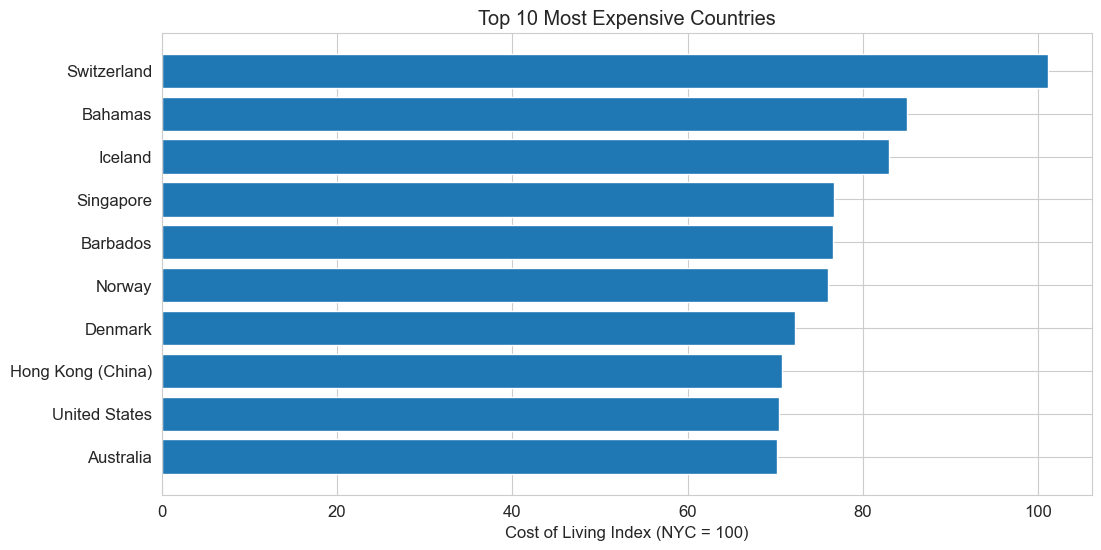

In [14]:
plt.barh(y= top_10['Country'], width= top_10['Cost of Living Index'])
plt.xlabel('Cost of Living Index (NYC = 100)')
plt.title('Top 10 Most Expensive Countries')
plt.gca().invert_yaxis()
plt.savefig('visuals/top_10_most_expensive.png', dpi=150, bbox_inches='tight')
plt.show()

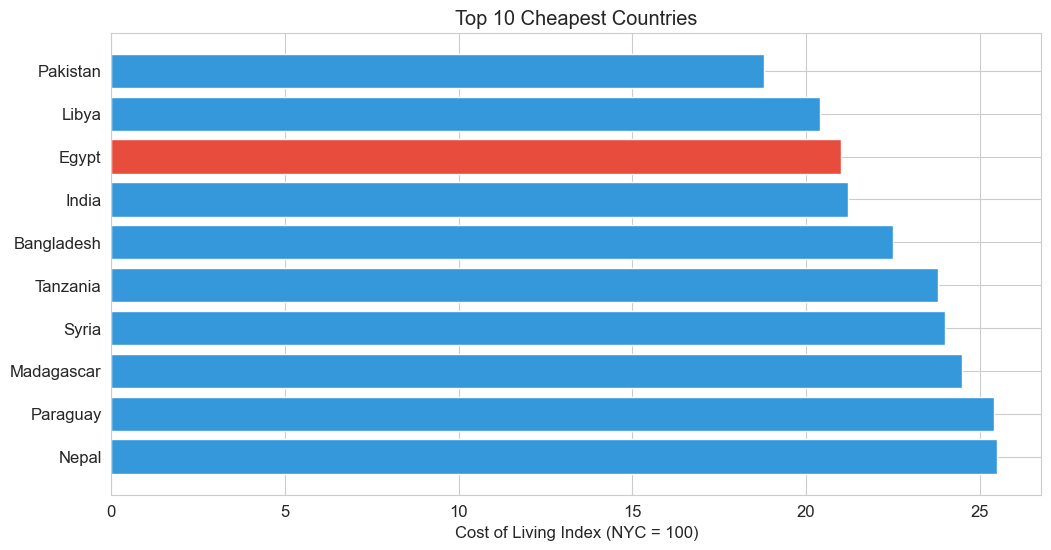

In [15]:
colors = ['#e74c3c' if c == 'Egypt' else '#3498db' for c in bottom_10['Country'].head(10)]
plt.barh(y= bottom_10['Country'], width= bottom_10['Cost of Living Index'].head(10), color=colors)
plt.xlabel('Cost of Living Index (NYC = 100)')
plt.title('Top 10 Cheapest Countries')
plt.gca().invert_yaxis()
plt.savefig('visuals/top_10_cheapest.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.2 Cost of Living vs Purchasing Power

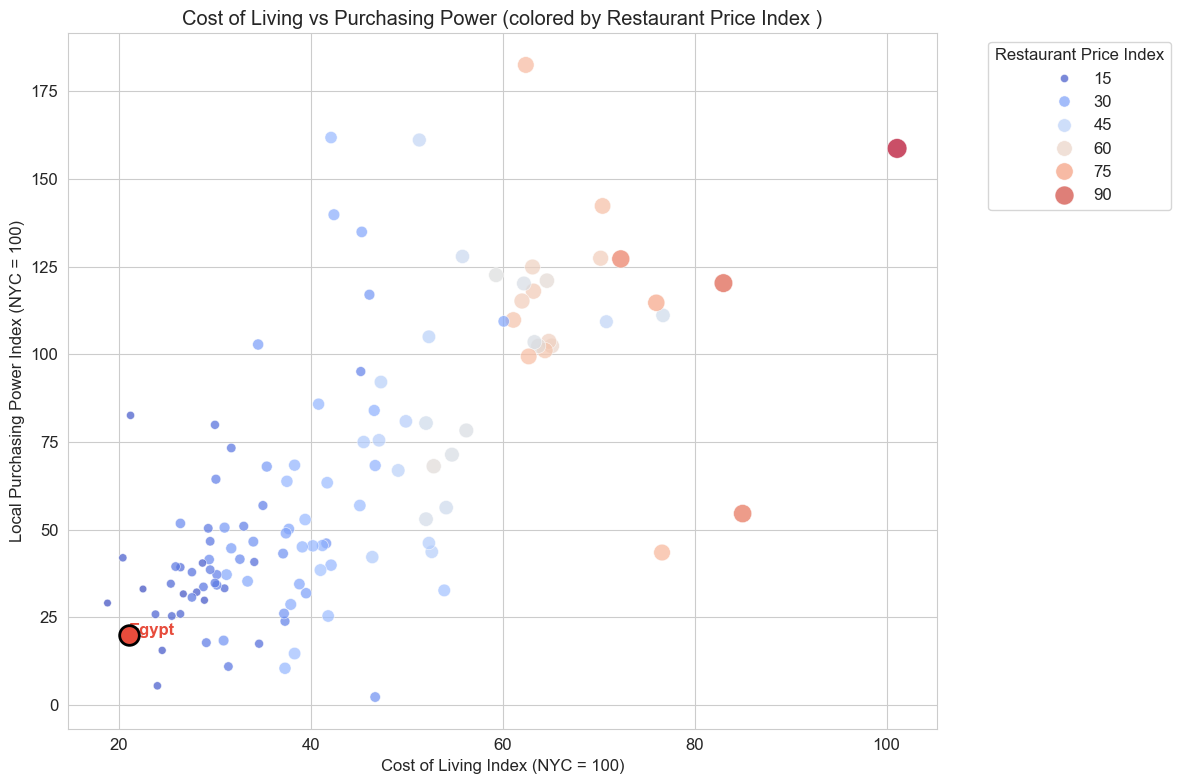

In [16]:
plt.figure(figsize=(12, 8))

sns.scatterplot(data= country, x='Cost of Living Index', y='Local Purchasing Power Index',
                hue='Restaurant Price Index',
                palette='coolwarm',
                size='Restaurant Price Index',
                sizes=(30,200),
                alpha=0.7)
egypt = country[country['Country'] == 'Egypt']
plt.scatter(egypt['Cost of Living Index'], egypt['Local Purchasing Power Index'], color='#e74c3c', s=200, zorder=5, edgecolors='black', linewidth=2)
plt.annotate('Egypt', xy=(egypt['Cost of Living Index'].values[0], egypt['Local Purchasing Power Index'].values[0]), fontsize=12, fontweight='bold', color='#e74c3c')

plt.xlabel('Cost of Living Index (NYC = 100)')
plt.ylabel('Local Purchasing Power Index (NYC = 100)')
plt.title('Cost of Living vs Purchasing Power (colored by Restaurant Price Index )')
plt.legend(title='Restaurant Price Index', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('visuals/cost_vs_purchasing_power.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Correlation Between Cost of Living Indices

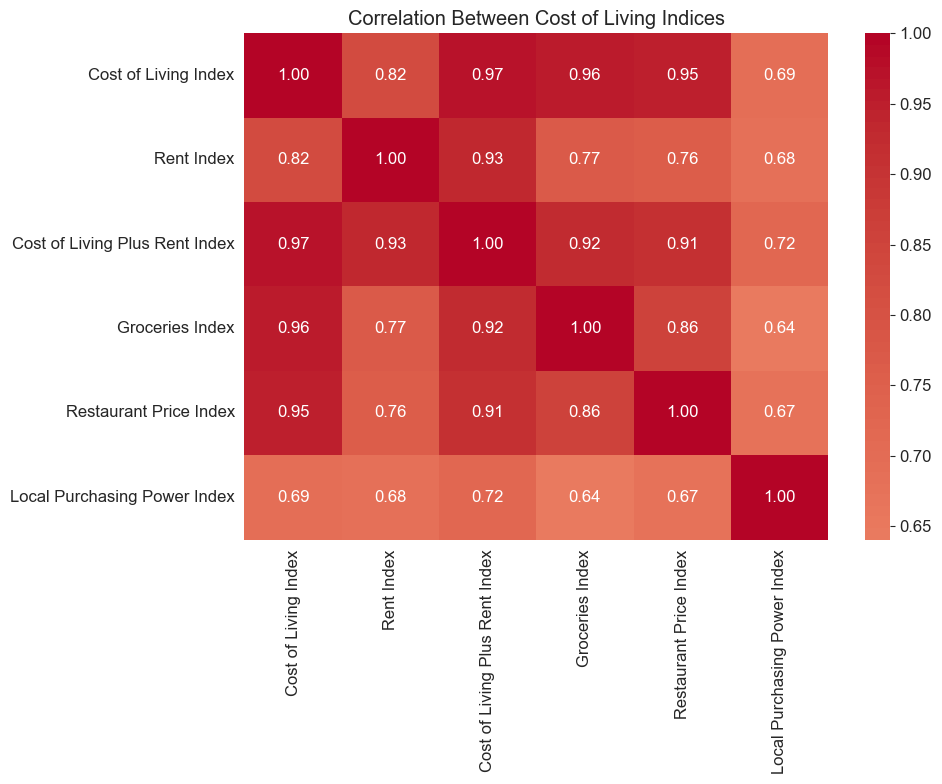

In [17]:
plt.figure(figsize=(10,8))

correlation = country.drop(columns=['Country']).corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm',  center=0, fmt='.2f')

plt.title('Correlation Between Cost of Living Indices')
plt.tight_layout()
plt.savefig('visuals/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Regional Averages

In [18]:
regions = {
    'Western Europe': ['Switzerland', 'Iceland', 'Norway', 'Denmark', 'Ireland', 'Netherlands', 'Finland', 'Belgium', 'Austria', 'France', 'Germany', 'Sweden', 'Italy', 'Spain', 'Portugal', 'Greece', 'Malta', 'Luxembourg', 'United Kingdom', 'Cyprus'],
    'Eastern Europe': ['Czech Republic', 'Estonia', 'Slovenia', 'Croatia', 'Lithuania', 'Latvia', 'Slovakia', 'Hungary', 'Poland', 'Romania', 'Bulgaria', 'Serbia', 'Montenegro', 'Bosnia And Herzegovina', 'North Macedonia', 'Albania', 'Moldova', 'Belarus', 'Ukraine', 'Russia', 'Georgia', 'Armenia', 'Azerbaijan', 'Kosovo (Disputed Territory)', 'Kazakhstan', 'Kyrgyzstan', 'Uzbekistan'],
    'North America': ['United States', 'Canada', 'Mexico'],
    'South America': ['Uruguay', 'Chile', 'Costa Rica', 'Panama', 'Colombia', 'Brazil', 'Peru', 'Ecuador', 'Argentina', 'Paraguay', 'Bolivia', 'El Salvador', 'Guatemala', 'Venezuela'],
    'East Asia': ['Singapore', 'Hong Kong (China)', 'South Korea', 'Japan', 'China', 'Taiwan', 'Mongolia'],
    'South/Southeast Asia': ['Thailand', 'Malaysia', 'Philippines', 'Vietnam', 'Cambodia', 'Myanmar', 'Indonesia', 'India', 'Sri Lanka', 'Bangladesh', 'Nepal', 'Pakistan'],
    'MENA': ['United Arab Emirates', 'Bahrain', 'Qatar', 'Saudi Arabia', 'Oman', 'Kuwait', 'Lebanon', 'Jordan', 'Turkey', 'Morocco', 'Tunisia', 'Egypt', 'Libya', 'Syria', 'Iraq', 'Iran', 'Israel', 'Palestine', 'Algeria'],
    'Sub-Saharan Africa': ['South Africa', 'Kenya', 'Nigeria', 'Ghana', 'Tanzania', 'Uganda', 'Ethiopia', 'Rwanda', 'Mauritius', 'Madagascar', 'Cameroon', 'Zimbabwe', 'Botswana'],
    'Oceania': ['Australia', 'New Zealand', 'Fiji'],
    'Caribbean': ['Bahamas', 'Barbados', 'Trinidad And Tobago', 'Jamaica', 'Dominican Republic', 'Puerto Rico', 'Cuba']
}

region_map = {}
for region, countries in regions.items():
    for c in countries:
        region_map[c] = region

country['Region'] = country['Country'].map(region_map)

print(f"Countries without a region: {country[country['Region'].isna()]['Country'].tolist()}")

Countries without a region: []


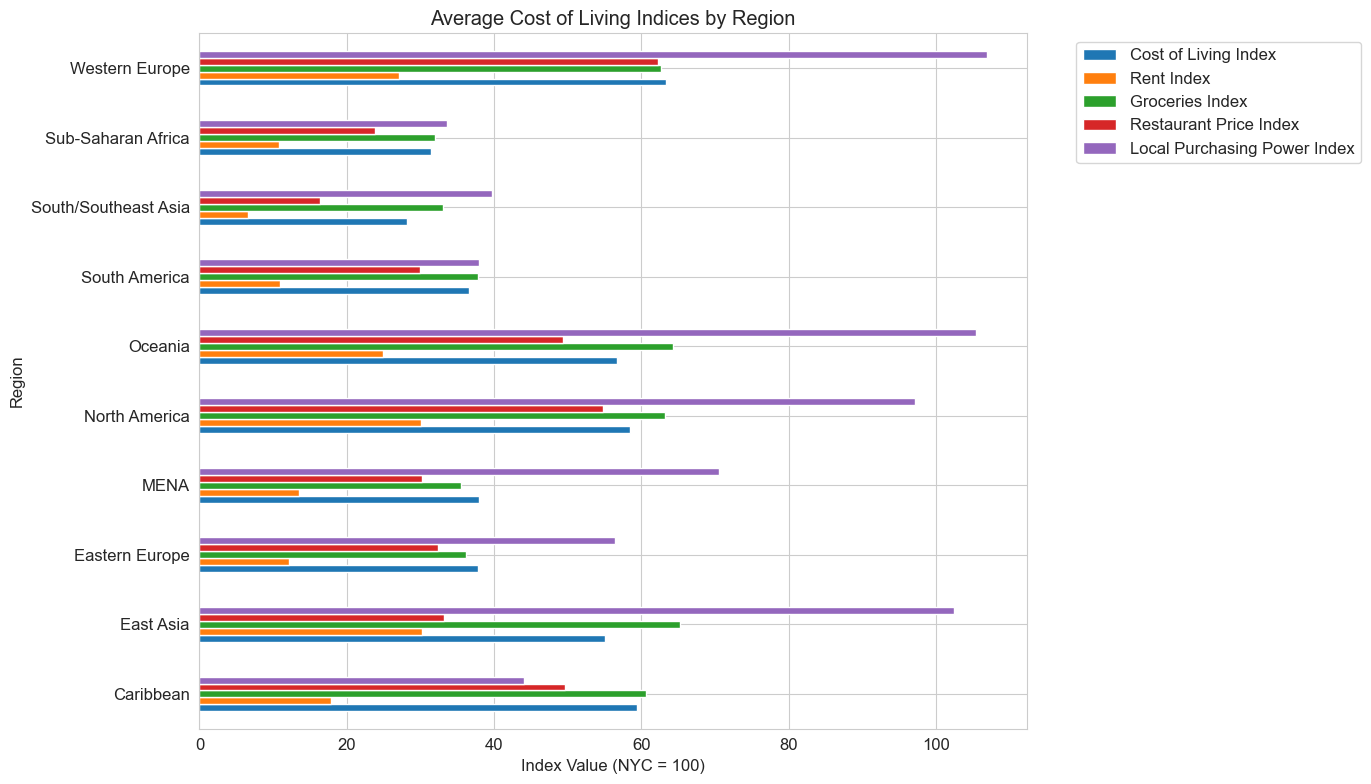

In [19]:
regional_avg = country.groupby('Region')[['Cost of Living Index', 'Rent Index', 'Groceries Index', 'Restaurant Price Index', 'Local Purchasing Power Index']].mean()
regional_avg.sort_values('Cost of Living Index', ascending=True)

regional_avg.plot(kind='barh', figsize=(14, 8))

plt.xlabel('Index Value (NYC = 100)')
plt.title('Average Cost of Living Indices by Region')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('visuals/regional_averages.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 3 Observations

Egypt ranks as the 3rd cheapest country globally by cost of living index. However, being cheap doesn't mean life is easy — Egypt also has one of the lowest purchasing power scores (20.0), meaning residents earn far less relative to what things cost compared to wealthier nations.

The scatter plot shows that cost of living and purchasing power don't always go hand in hand. Some cheap countries like India still have decent purchasing power (82.6), while Egypt's is significantly lower.

The correlation heatmap shows all indices are strongly correlated (0.64+), meaning expensive countries tend to be expensive across the board. Purchasing power has the weakest relationship with the other indices, confirming it's driven by income levels rather than just prices.

Regionally, MENA sits in the middle — moderate costs but with wide variation between countries like Qatar and Egypt. Western Europe is the most expensive overall while South/Southeast Asia is the cheapest.

## Phase 4: Egypt vs MENA Comparison

Now let's zoom into the MENA region and see where Egypt stands among its neighbors.

### 4.1 MENA Country-Level Comparison

In [20]:
mena_countries = ['Egypt', 'United Arab Emirates', 'Saudi Arabia', 'Turkey', 'Morocco', 'Tunisia', 'Jordan', 'Lebanon', 'Qatar', 'Bahrain', 'Kuwait', 'Oman', 'Israel', 'Palestine', 'Algeria', 'Libya', 'Syria', 'Iraq', 'Iran']

mena = country[country['Country'].isin(mena_countries)]

print(f"MENA countries found: {len(mena)}")
mena.sort_values('Cost of Living Index', ascending=False)

MENA countries found: 19


,Country,Cost of Living Index,Rent Index,Cost of Living Plus Rent Index,Groceries Index,Restaurant Price Index,Local Purchasing Power Index,Region
18,Israel,62.7,27.1,45.6,59.6,68.0,99.4,MENA
26,United Arab Emirates,55.8,41.3,48.9,45.3,49.2,127.9,MENA
33,Bahrain,52.3,20.5,37.0,46.9,44.7,105.0,MENA
36,Qatar,51.3,36.1,44.0,43.9,47.2,161.1,MENA
47,Saudi Arabia,45.3,11.3,29.0,41.6,30.9,134.9,MENA
50,Oman,42.4,12.2,27.9,39.9,33.1,139.8,MENA
51,Kuwait,42.1,22.6,32.7,34.5,36.4,161.8,MENA
53,Lebanon,41.8,13.4,28.1,32.2,37.1,25.4,MENA
55,Palestine,41.6,8.0,25.5,40.7,27.4,46.1,MENA
56,Jordan,41.2,7.2,24.9,37.1,34.8,45.5,MENA


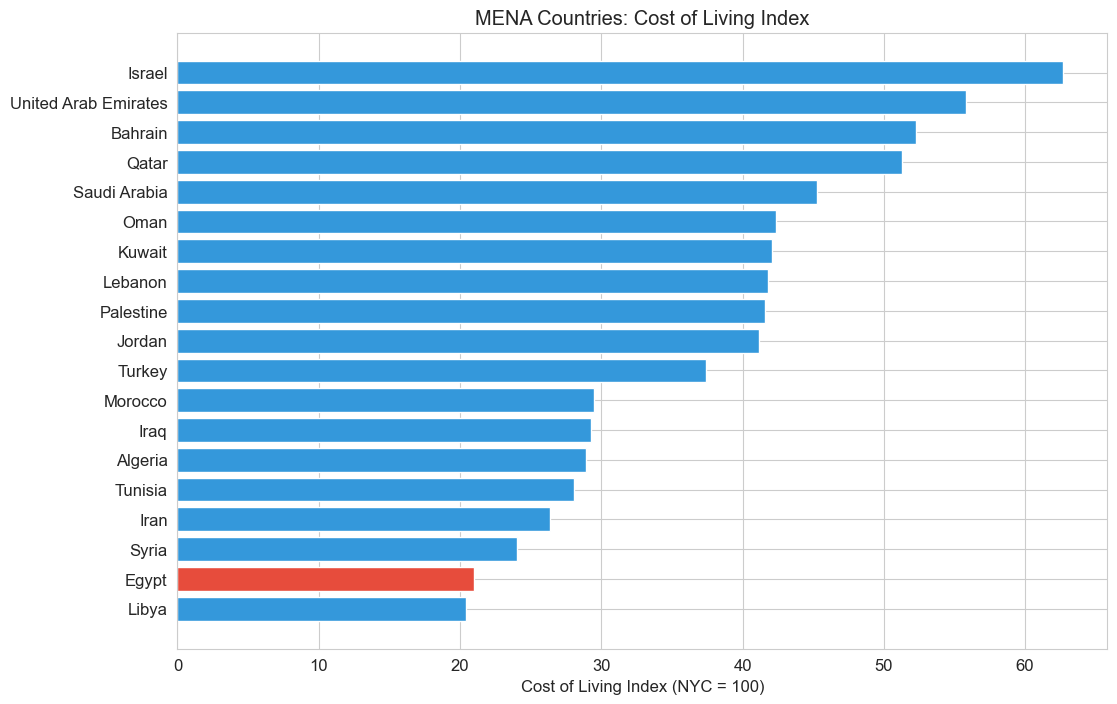

In [21]:
mena_sorted = mena.sort_values('Cost of Living Index', ascending=True)

colors = ['#e74c3c' if c == 'Egypt' else '#3498db' for c in mena_sorted['Country']]

plt.figure(figsize=(12, 8))
plt.barh(y=mena_sorted['Country'], width=mena_sorted['Cost of Living Index'], color=colors)
plt.xlabel('Cost of Living Index (NYC = 100)')
plt.title('MENA Countries: Cost of Living Index')
plt.savefig('visuals/mena_cost_of_living.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 MENA Value Score — Purchasing Power vs Cost of Living

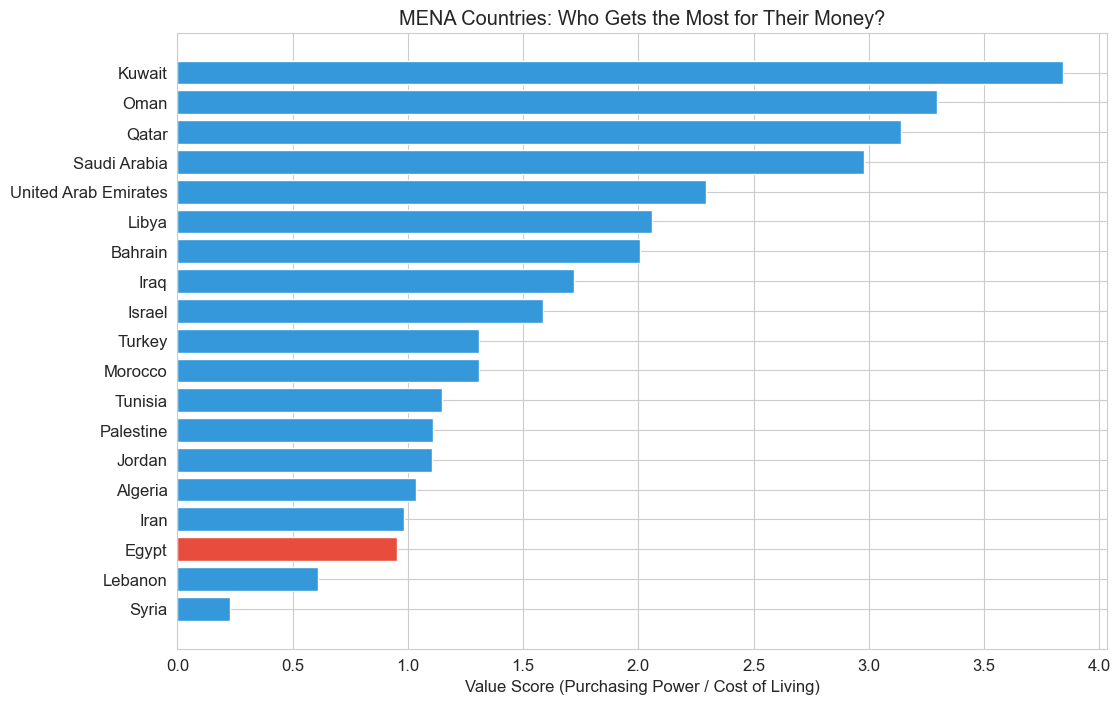

In [22]:
mena_sorted['Value Score'] = mena_sorted['Local Purchasing Power Index'] / mena_sorted['Cost of Living Index']

mena_value = mena_sorted.sort_values('Value Score', ascending=True)

colors = ['#e74c3c' if c == 'Egypt' else '#3498db' for c in mena_value['Country']]

plt.figure(figsize=(12, 8))
plt.barh(y=mena_value['Country'], width=mena_value['Value Score'], color=colors)
plt.xlabel('Value Score (Purchasing Power / Cost of Living)')
plt.title('MENA Countries: Who Gets the Most for Their Money?')
plt.savefig('visuals/mena_value_score.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Cairo vs MENA Peer Cities

In [23]:
peer_cities = ['Cairo', 'Dubai', 'Riyadh', 'Istanbul', 'Casablanca']

peers = city[city['city'].isin(peer_cities)]

print(f"Cities found: {peers['city'].tolist()}")
peers[['city', 'country', 'meal_inexpensive', 'cappuccino', 'rent_1bed_center', 'utilities_monthly', 'avg_monthly_salary']]

Cities found: ['Cairo', 'Istanbul', 'Riyadh', 'Casablanca', 'Dubai']


,city,country,meal_inexpensive,cappuccino,rent_1bed_center,utilities_monthly,avg_monthly_salary
19,Cairo,Egypt,4.07,1.76,197.56,26.99,202.53
21,Istanbul,Turkey,5.36,1.84,538.89,67.55,382.09
67,Riyadh,Saudi Arabia,6.65,3.84,745.33,93.64,2212.23
128,Casablanca,Morocco,3.63,1.75,406.46,37.21,476.34
191,Dubai,United Arab Emirates,12.25,5.30,1752.39,193.17,4395.91


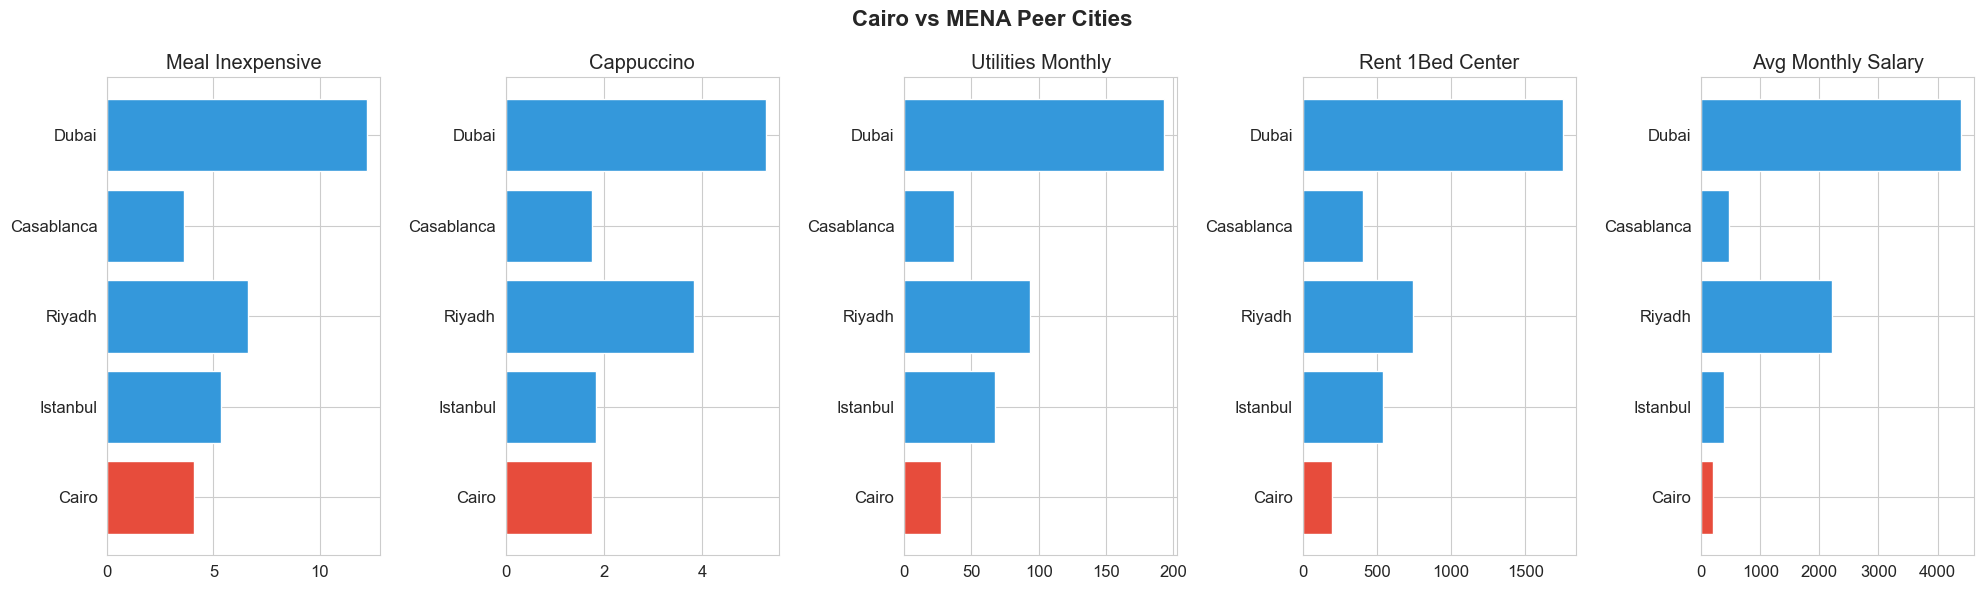

In [24]:
categories = ['meal_inexpensive', 'cappuccino', 'utilities_monthly', 'rent_1bed_center', 'avg_monthly_salary']

fig, axes = plt.subplots(1, len(categories), figsize=(20, 6))

for i, cat in enumerate(categories):
    colors = ['#e74c3c' if c == 'Cairo' else '#3498db' for c in peers['city']]
    axes[i].barh(y=peers['city'], width=peers[cat], color=colors)
    axes[i].set_title(cat.replace('_', ' ').title())

plt.suptitle('Cairo vs MENA Peer Cities', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/cairo_vs_peers.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 4 Observations

Egypt ranks second cheapest in the MENA region, only ahead of Libya. But the value score tells a different story — when you factor in what people actually earn, Egypt drops to third from the bottom, with only Lebanon and Syria performing worse. The Gulf states (Kuwait, Oman, Qatar, Saudi Arabia) dominate the value rankings thanks to high salaries and moderate costs.

At the city level, Cairo is the cheapest across every category compared to Dubai, Riyadh, Istanbul, and Casablanca. But the salary gap is massive — Cairo's average monthly salary ($202) is roughly 20x less than Dubai's ($4,395) and 10x less than Riyadh's ($2,212). Cairo's rent for a 1-bedroom in the center ($197) is almost equal to the entire average salary, which puts the "cheap cost of living" into perspective.

Being cheap doesn't mean much if the income doesn't match.

## Phase 5: Egypt Deep Dive — Currency & Inflation Sensitivity

In this section we shift from a snapshot analysis to a time-series view. The previous phases used 2024 data to show where Egypt stands today. Here we look at how Egypt got here by tracking the EGP/USD exchange rate and inflation from 2022 to 2026.

### 5.1 EGP/USD Exchange Rate Over Time

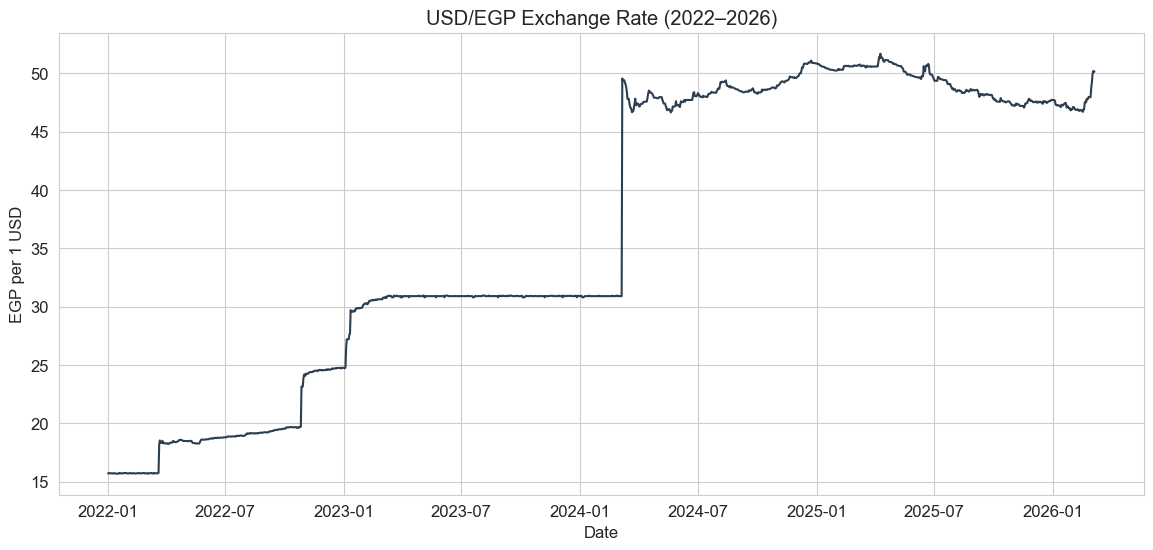

In [25]:
plt.figure(figsize=(14, 6))

plt.plot(exchange['Date'], exchange['Price'], color='#2c3e50', linewidth=1.5)

plt.xlabel('Date')
plt.ylabel('EGP per 1 USD')
plt.title('USD/EGP Exchange Rate (2022–2026)')
plt.show()

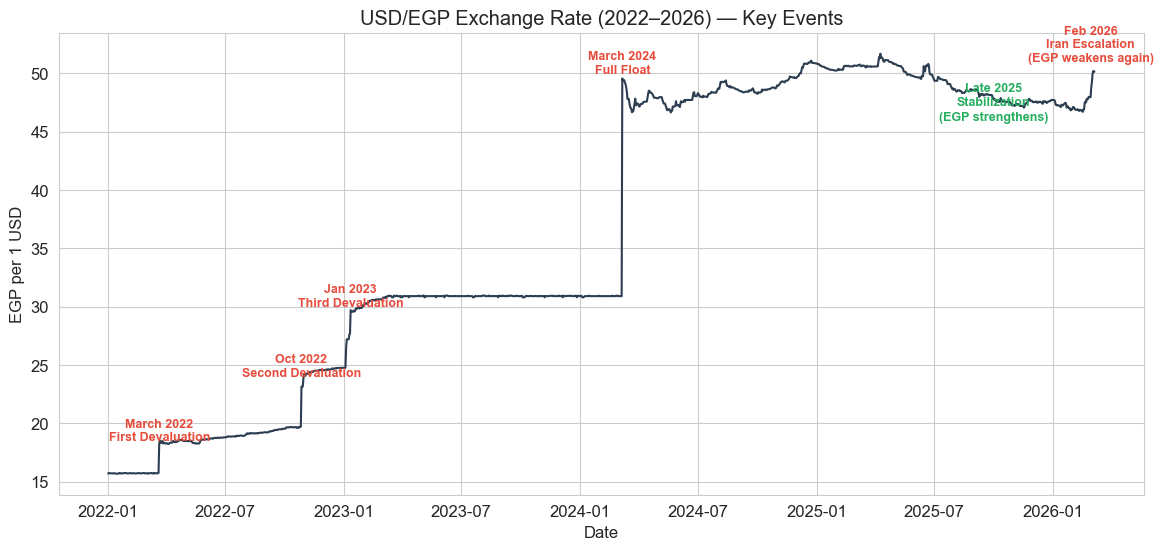

In [26]:
plt.figure(figsize=(14, 6))

plt.plot(exchange['Date'], exchange['Price'], color='#2c3e50', linewidth=1.5)

plt.annotate('March 2022\nFirst Devaluation', xy=(pd.Timestamp('2022-03-21'), 18.5), fontsize=9, color='#e74c3c', fontweight='bold', ha='center')

plt.annotate('Oct 2022\nSecond Devaluation', xy=(pd.Timestamp('2022-10-27'), 24), fontsize=9, color='#e74c3c', fontweight='bold', ha='center')

plt.annotate('Jan 2023\nThird Devaluation', xy=(pd.Timestamp('2023-01-11'), 30), fontsize=9, color='#e74c3c', fontweight='bold', ha='center')

plt.annotate('March 2024\nFull Float', xy=(pd.Timestamp('2024-03-06'), 50), fontsize=9, color='#e74c3c', fontweight='bold', ha='center')

plt.annotate('Late 2025\nStabilization\n(EGP strengthens)', xy=(pd.Timestamp('2025-10-01'), 46), fontsize=9, color='#27ae60', fontweight='bold', ha='center')

plt.annotate('Feb 2026\nIran Escalation\n(EGP weakens again)', xy=(pd.Timestamp('2026-02-28'), 51), fontsize=9, color='#e74c3c', fontweight='bold', ha='center')

plt.xlabel('Date')
plt.ylabel('EGP per 1 USD')
plt.title('USD/EGP Exchange Rate (2022–2026) — Key Events')
plt.savefig('visuals/exchange_rate_annotated.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Exchange Rate vs Inflation — Dual Axis Timeline

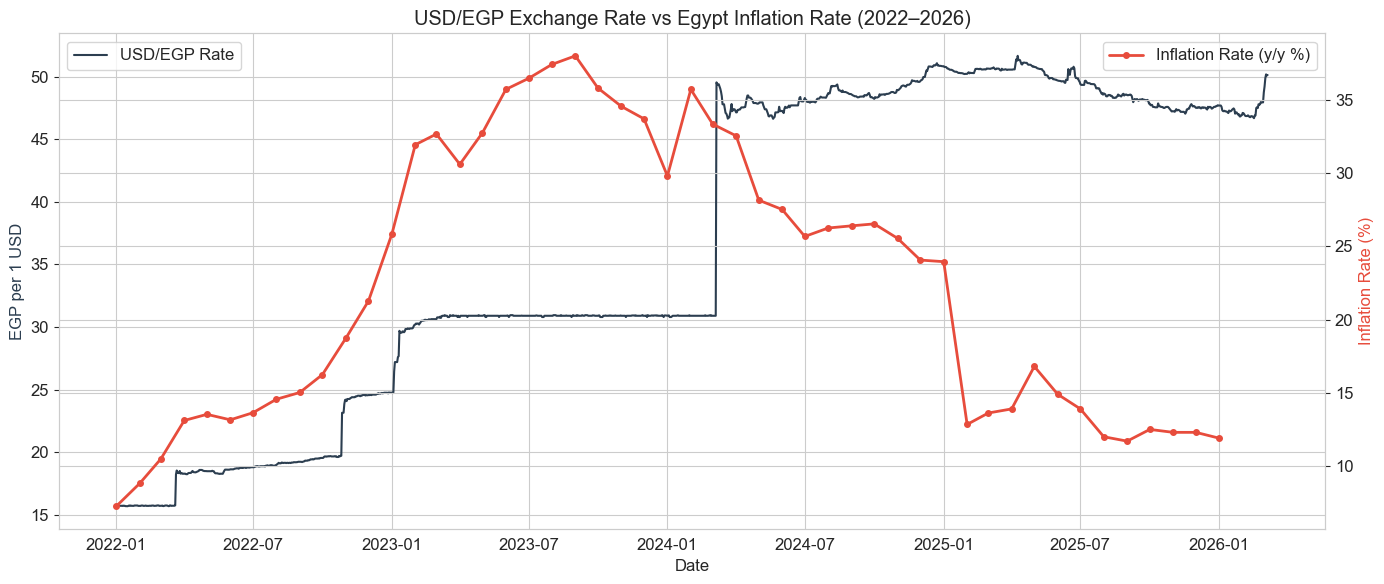

In [27]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(exchange['Date'], exchange['Price'], color='#2c3e50', linewidth=1.5, label='USD/EGP Rate')
ax1.set_xlabel('Date')
ax1.set_ylabel('EGP per 1 USD', color='#2c3e50')

ax2 = ax1.twinx()
ax2.plot(inflation['Date'], inflation['inflation_rate'], color='#e74c3c', linewidth=2, marker='o', markersize=4, label='Inflation Rate (y/y %)')
ax2.set_ylabel('Inflation Rate (%)', color='#e74c3c')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.title('USD/EGP Exchange Rate vs Egypt Inflation Rate (2022–2026)')
plt.tight_layout()
plt.savefig('visuals/exchange_vs_inflation.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 5 Observations

The EGP lost over 200% of its value against the USD between 2022 and 2024, going from roughly 15.7 to over 50 across three devaluations and a full currency float in March 2024.

Inflation followed each devaluation closely, peaking at around 38% year-over-year in late 2023. As the currency stabilized through 2024 and into 2025, inflation gradually cooled to around 12% by early 2026. The dual-axis chart shows a visible correlation between currency moves and inflation, though multiple factors beyond the exchange rate contribute to inflation.

What stands out most is how fragile the recovery is. By late 2025, the EGP had strengthened from ~51 to ~47 as the economy stabilized. Then in February 2026, the Iran escalation hit — shipping companies rerouted away from the Suez Canal, Israeli gas supplies to Egypt were halted, and foreign investors pulled out. Within days the EGP jumped back to ~50, effectively erasing months of progress.

This shows that Egypt's economy is heavily exposed to geopolitical events, particularly anything that disrupts the Suez Canal, energy imports, or investor confidence. The data doesn't prove causation, but the pattern is clear — external shocks translate into currency pressure almost immediately.

## Phase 6: Conclusions

### Key Findings

1. **Egypt is one of the cheapest countries globally** — ranking 3rd lowest by cost of living index. But cheap doesn't mean affordable. Egypt's purchasing power index (20.0) is among the lowest in the world, meaning residents earn very little relative to what things cost.

2. **The MENA value score reveals the real picture** — Gulf states like Kuwait, Oman, and Qatar offer residents 3-4x more value for their money than Egypt. Despite being cheap, Egypt ranks 3rd worst in the region for actual purchasing power relative to cost.

3. **Cairo's salary gap is the core issue** — at $202/month average salary, Cairo residents spend nearly their entire income on rent alone for a 1-bedroom apartment in the city center ($197). Meanwhile Dubai's salary ($4,395) is over 20x higher.

4. **Currency devaluation and inflation are tightly linked** — every major EGP devaluation was followed by a spike in inflation. The EGP lost over 200% of its value between 2022 and 2024, and inflation peaked at ~38% in late 2023.

5. **Egypt's economy is highly sensitive to external shocks** — by late 2025, the currency had stabilized around 47 EGP per dollar. The February 2026 Iran escalation reversed months of progress within days, pushing the rate back to ~50 as Suez Canal traffic dropped and foreign investors exited.

### Limitations

- The cost of living data is a 2024 snapshot, not a time series. We cannot track how prices changed year over year using this dataset alone.
- City-level data is crowd-sourced from Numbeo, which may contain biases toward cities with more contributors.
- The inflation and exchange rate analysis shows correlation, not causation. Many factors beyond geopolitical events influence these metrics.
- Salary data in the city dataset may not reflect the full picture, as informal economy earnings are not captured.

### Next Steps

- Build an interactive Tableau dashboard using the cleaned data from this project to allow users to explore the comparisons visually.
- With more time, sourcing historical cost of living data across multiple years would allow tracking how Egypt's prices shifted alongside the devaluations rather than relying on a single snapshot.
- Suez Canal revenue data from official sources could add another layer to the Egypt sensitivity analysis, though this data is not easily accessible in a clean format.